<a href="https://colab.research.google.com/github/ksohyun916/DSCI-303-Final-Project-App-Ratings/blob/main/Final_Project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [ ]:
#WL file upload

from google.colab import drive
drive.mount("/content/drive")

path_to_data_folder = "/content/drive/MyDrive/Colab Notebooks/303/"

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/content/drive/MyDrive/Colab Notebooks/303/")

df = pd.read_csv('AppleStore.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


#### Preparations


In [ ]:
# Print high-level information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7197 entries, 0 to 7196
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7197 non-null   int64  
 1   id                7197 non-null   int64  
 2   track_name        7197 non-null   object 
 3   size_bytes        7197 non-null   int64  
 4   currency          7197 non-null   object 
 5   price             7197 non-null   float64
 6   rating_count_tot  7197 non-null   int64  
 7   rating_count_ver  7197 non-null   int64  
 8   user_rating       7197 non-null   float64
 9   user_rating_ver   7197 non-null   float64
 10  ver               7197 non-null   object 
 11  cont_rating       7197 non-null   object 
 12  prime_genre       7197 non-null   object 
 13  sup_devices.num   7197 non-null   int64  
 14  ipadSc_urls.num   7197 non-null   int64  
 15  lang.num          7197 non-null   int64  
 16  vpp_lic           7197 non-null   int64  


Because every feature has complete entries, we DO NOT have missing data. However, we will drop irrelevant columns now.


In [ ]:
#drop first column (app index)
df = df.drop(df.columns[0], axis=1)
#drop id column (doesn't provide valuable information)
df = df.drop('id', axis=1)
#drop track_name column (will not look at app name in algorithms)
df = df.drop('track_name', axis=1)
df.head()

,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


#### Distribution Analysis

In [ ]:
# Select Numerical features
df_num = df.select_dtypes(include= 'number')
df_num.head()

,size_bytes,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,100788224,3.99,21292,26,4.0,4.5,38,5,10,1
1,158578688,0.00,161065,26,4.0,3.5,37,5,23,1
2,100524032,0.00,188583,2822,3.5,4.5,37,5,3,1
3,128512000,0.00,262241,649,4.0,4.5,37,5,9,1
4,92774400,0.00,985920,5320,4.5,5.0,37,5,45,1


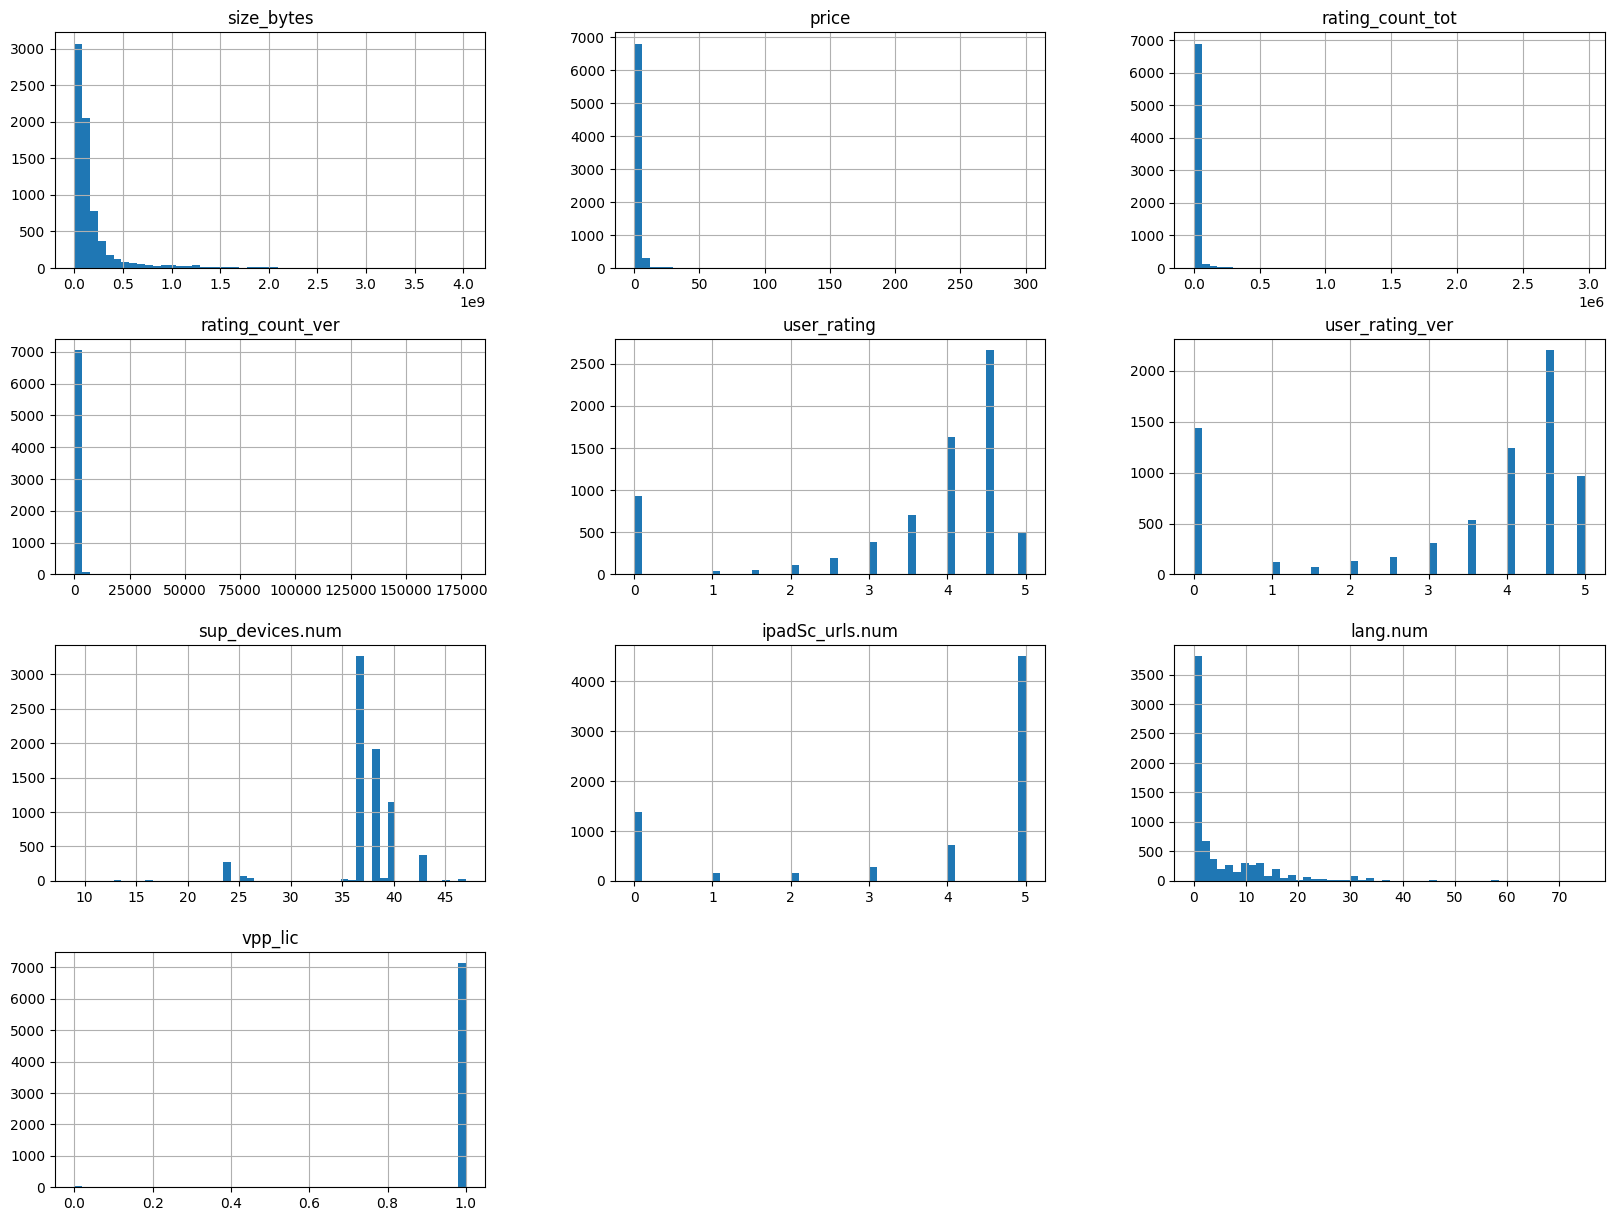

In [ ]:
#Plot distribution of numeric features
df_num.hist(figsize=(20,15), bins=50)
plt.show()

According to the plots, we can see that a lot of our features are heavily skewed. We can address this by transforming the heavily skewed features using log transformation. Specifically, the following features would benefit from a log transformation: size_bytes, price, rating_count_tot, rating_count_ver, lang.num

In [ ]:
df_cate = df.select_dtypes(include= 'object')
print('There is {} non numerical features including:\n{}'.format(len(df_cate.columns), df_cate.columns.tolist()))

There is 4 non numerical features including:
['currency', 'ver', 'cont_rating', 'prime_genre']


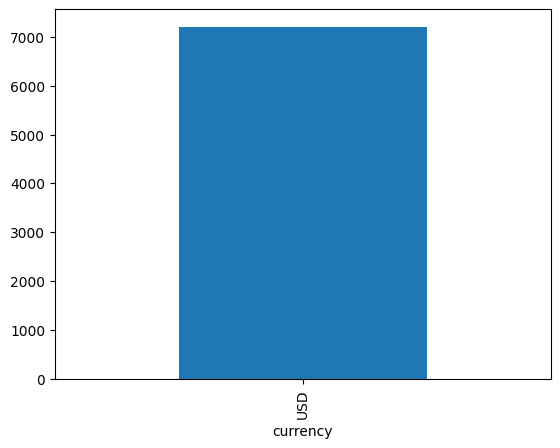

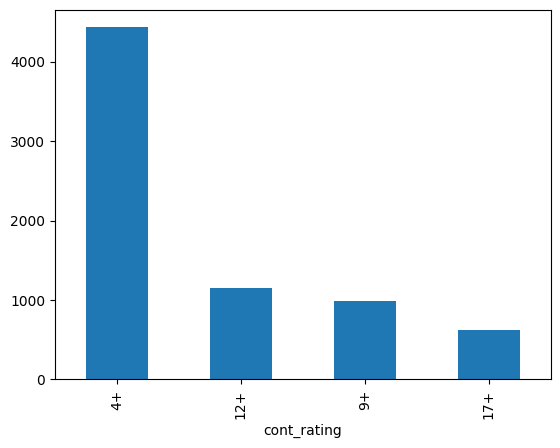

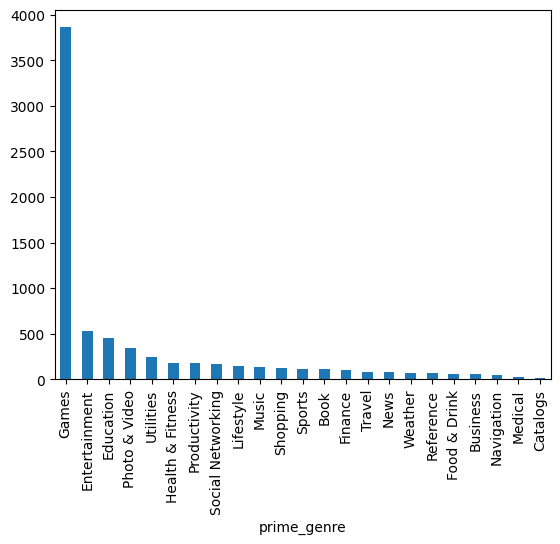

In [ ]:
#plot relevant non numerical features (currency, cont_rating, prime_genre)
df_cate['currency'].value_counts().plot(kind='bar')
plt.show()
df_cate['cont_rating'].value_counts().plot(kind='bar')
plt.show()
df_cate['prime_genre'].value_counts().plot(kind='bar')
plt.show()


#### Correlation Analysis

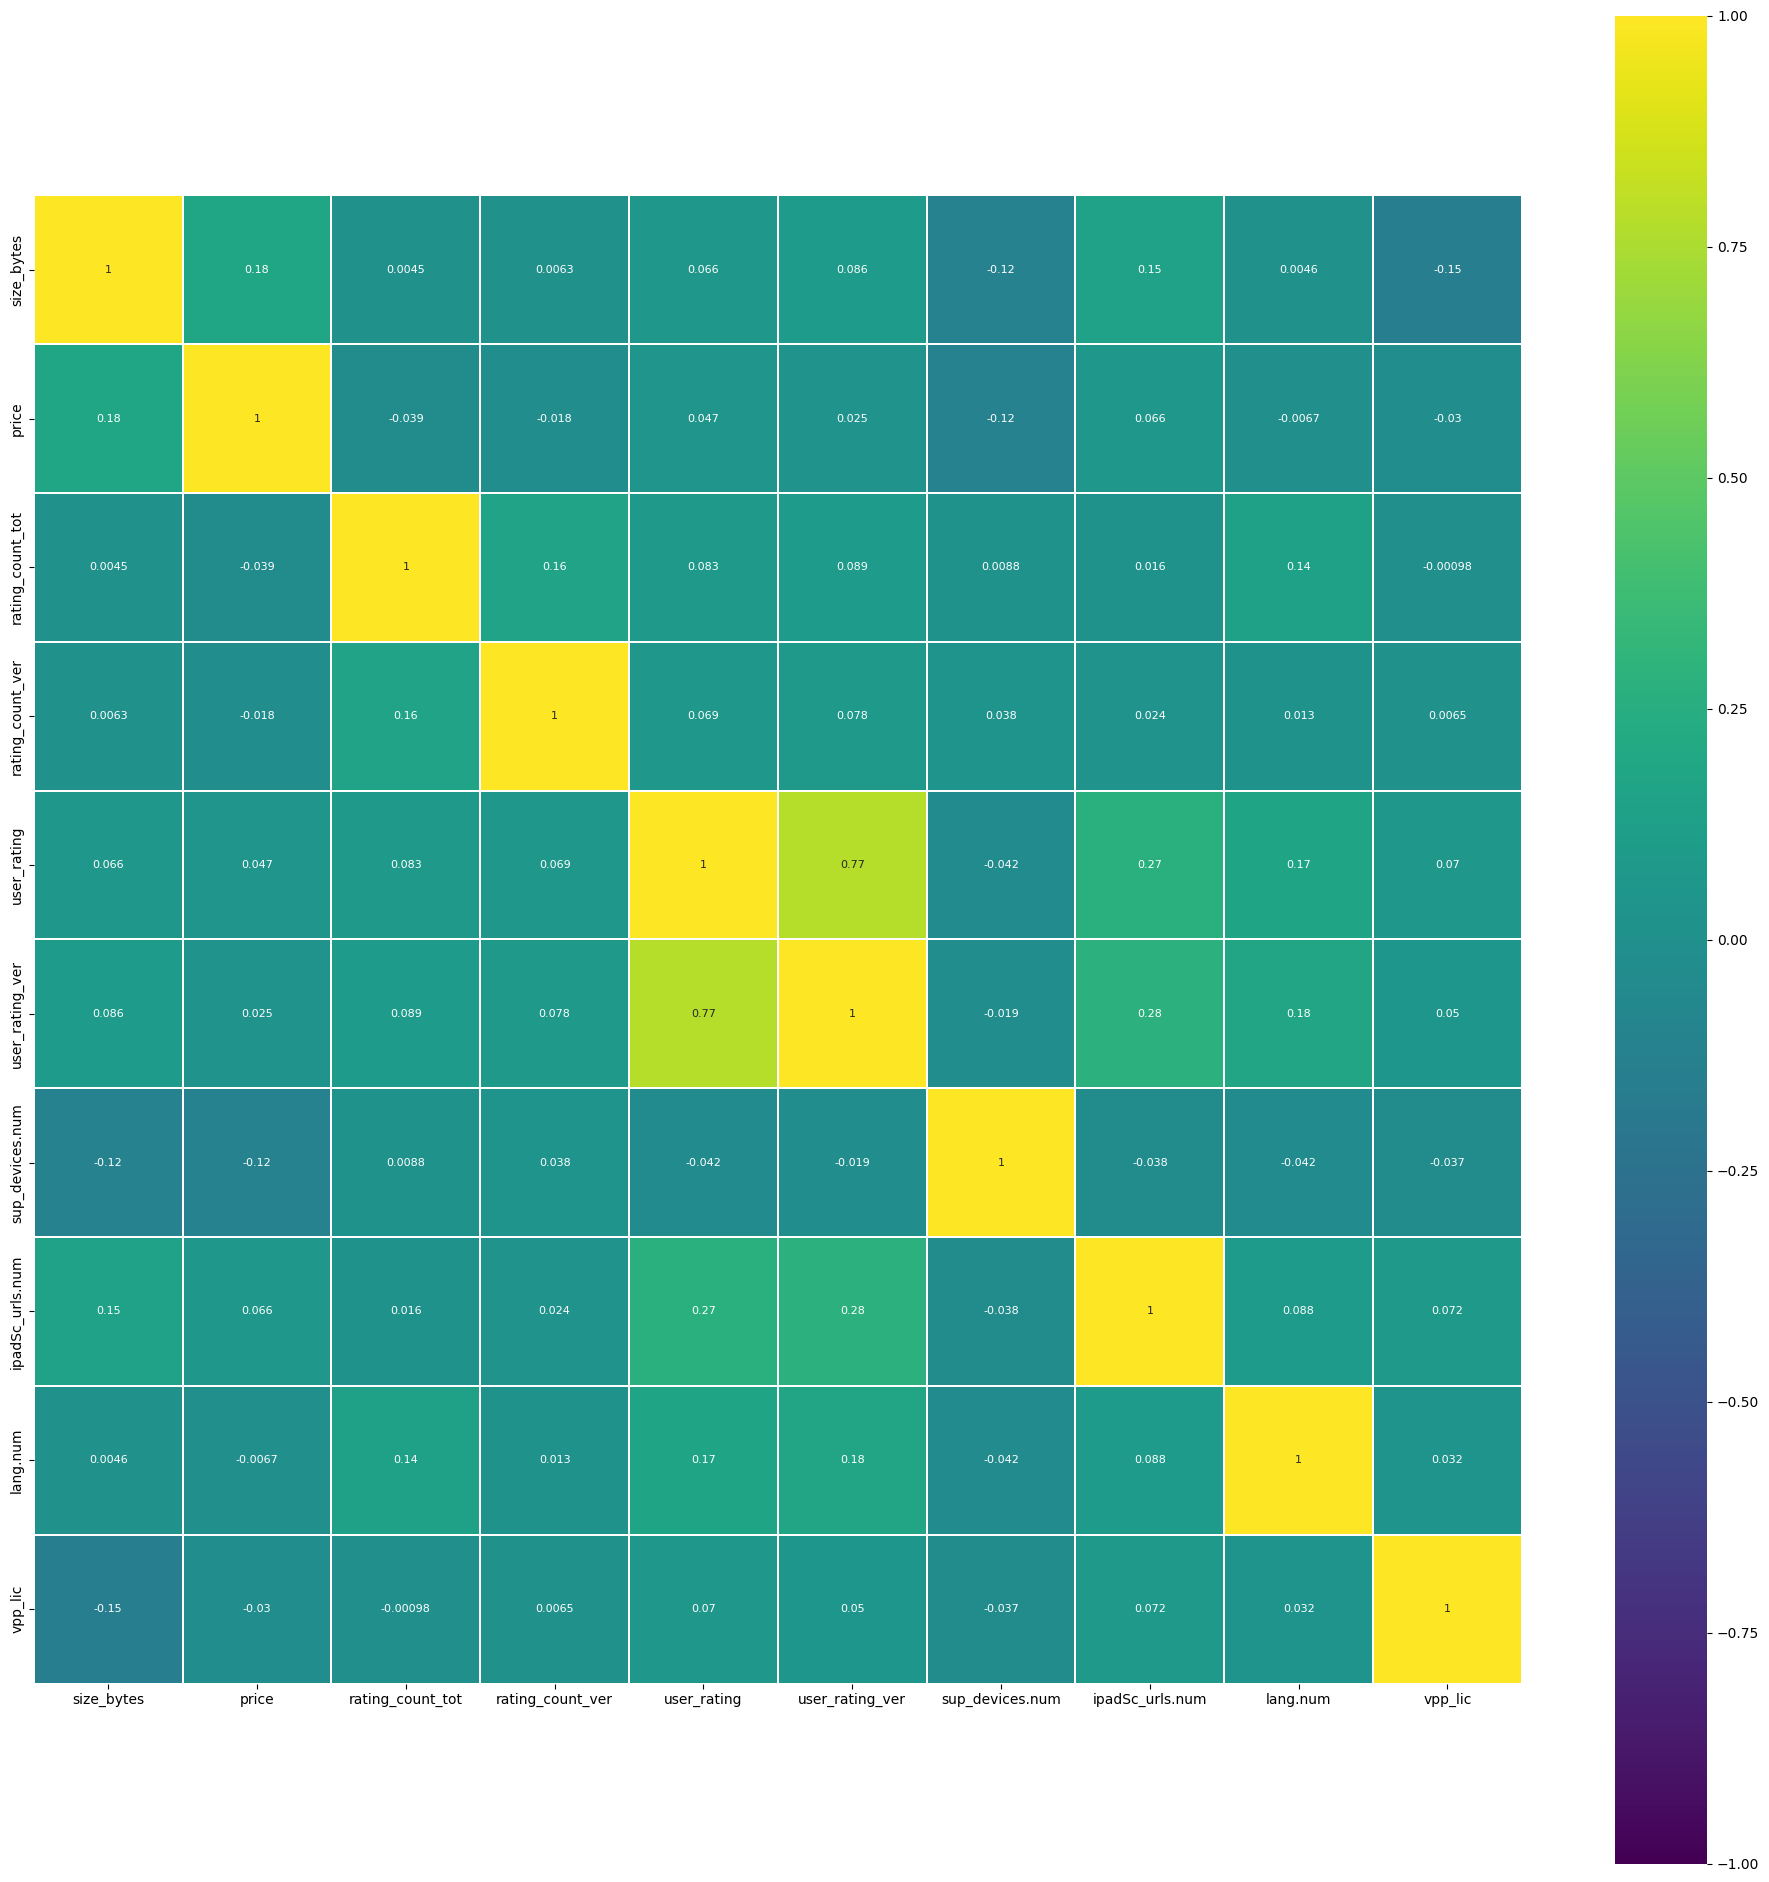

In [ ]:
# Select only numeric features before calculating correlation
df_corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(24, 24))

sns.heatmap(df_corr,
            cmap='viridis', vmax=1.0, vmin=-1.0, linewidths=0.1,
            annot=True, annot_kws={"size": 8}, square=True);

Now we'll try to find which features are strongly correlated with user_rating_ver. We'll store them in a list called golden_features_list. We'll reuse our df_num dataset to do so.

In [ ]:
#drop user_rating column from df_corr
df_corr = df_corr.drop('user_rating')

In [ ]:
#get the correlation between features and label (user_rating)
corr_label = df_corr['user_rating']
#rank the absolute values
corr_label = corr_label.abs().sort_values(ascending=False)
#print
print("The absolute value of correlations of numerical with user_rating are:")
print(corr_label)

The absolute value of correlations of numerical with user_rating are:
user_rating_ver     0.774140
ipadSc_urls.num     0.265671
lang.num            0.170976
rating_count_tot    0.083310
vpp_lic             0.069816
rating_count_ver    0.068754
size_bytes          0.066256
price               0.046601
sup_devices.num     0.042451
Name: user_rating, dtype: float64


There was only one feature that had a correlation of >0.5, user_rating_ver (rating for the specific version)

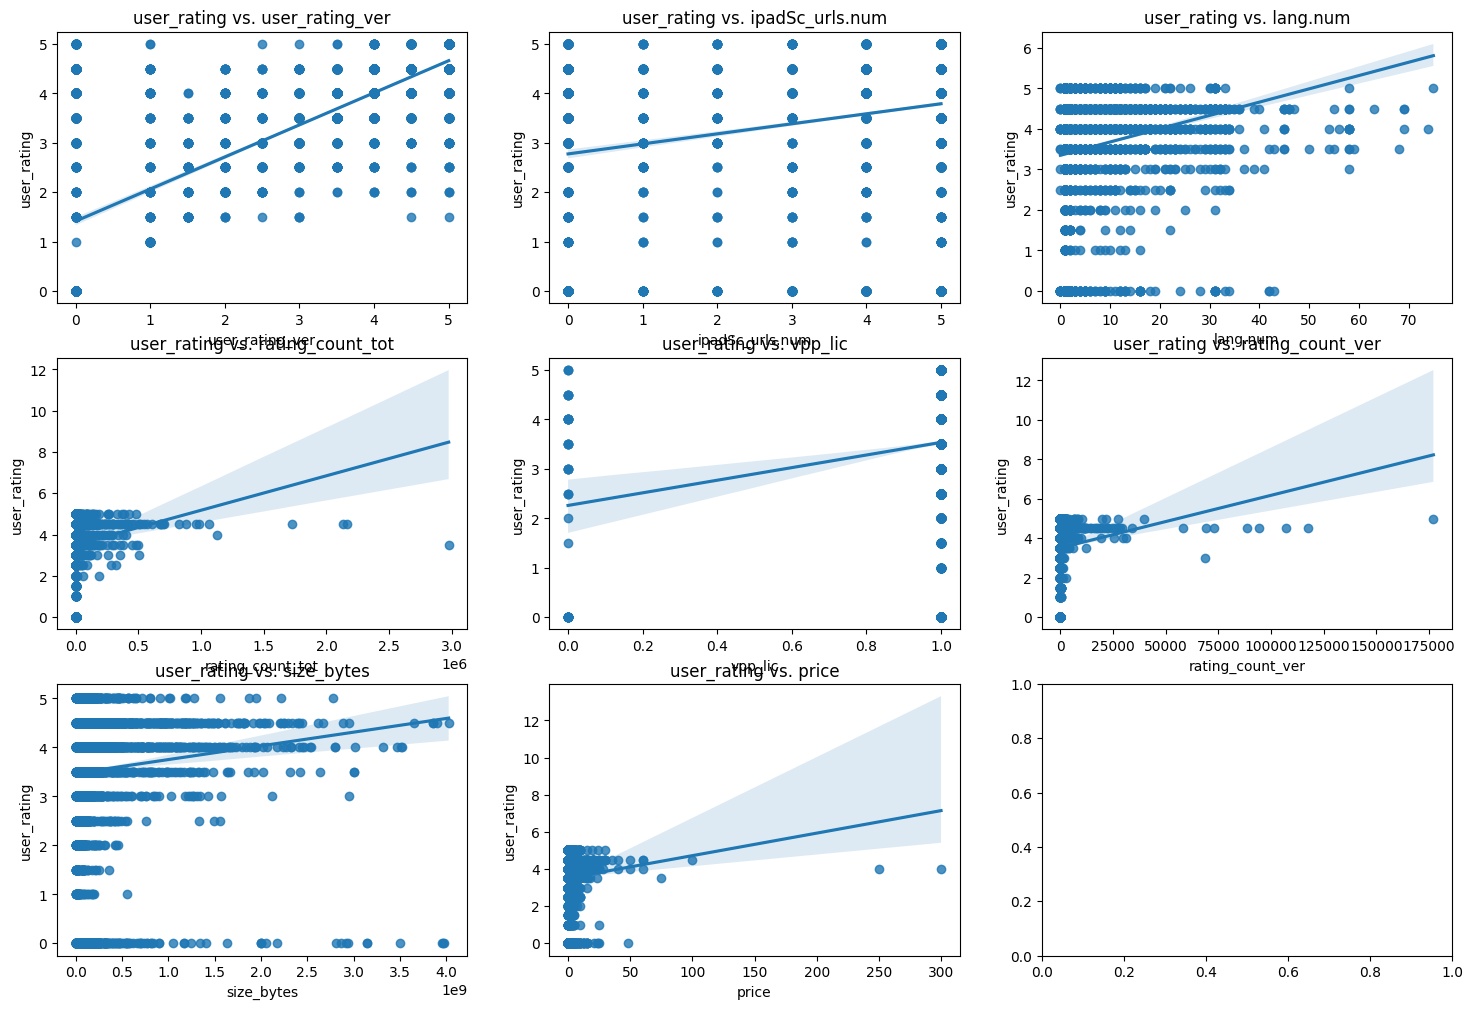

In [ ]:
fig, ax = plt.subplots(round(len(corr_label) / 3), 3, figsize = (18, 12))

for i, ax in enumerate(fig.axes):
    if i < len(corr_label) - 1:
        sns.regplot(x=df[corr_label.index[i]], y=df['user_rating'], ax=ax)
        ax.set_title('user_rating vs. {}'.format(corr_label.index[i]))

## Data Pre-Processing

In [ ]:
df = pd.read_csv('AppleStore.csv')
y = df.user_rating
# We won't use any label information during data pre-processing and feature engineering
df.drop(['user_rating'], axis=1, inplace=True)

In [ ]:
df_na = (df.isnull().sum() / len(df)) * 100
df_na = df_na.drop(df_na[df_na == 0].index).sort_values(ascending=False)[:30]
missing_data = pd.DataFrame({'Missing Ratio' :df_na})
missing_data.head()

,Missing Ratio


In [ ]:
#drop rows where user_rating is 0 from y, keeping track of the rows to drop in df
#user_rating of 0 means no rating has been provided
rows_to_drop = y[y == 0].index
y = y.drop(rows_to_drop)
df = df.drop(rows_to_drop)
print(df.shape)

(6268, 16)


Text(0.5, 1.0, 'Percent missing data by features')

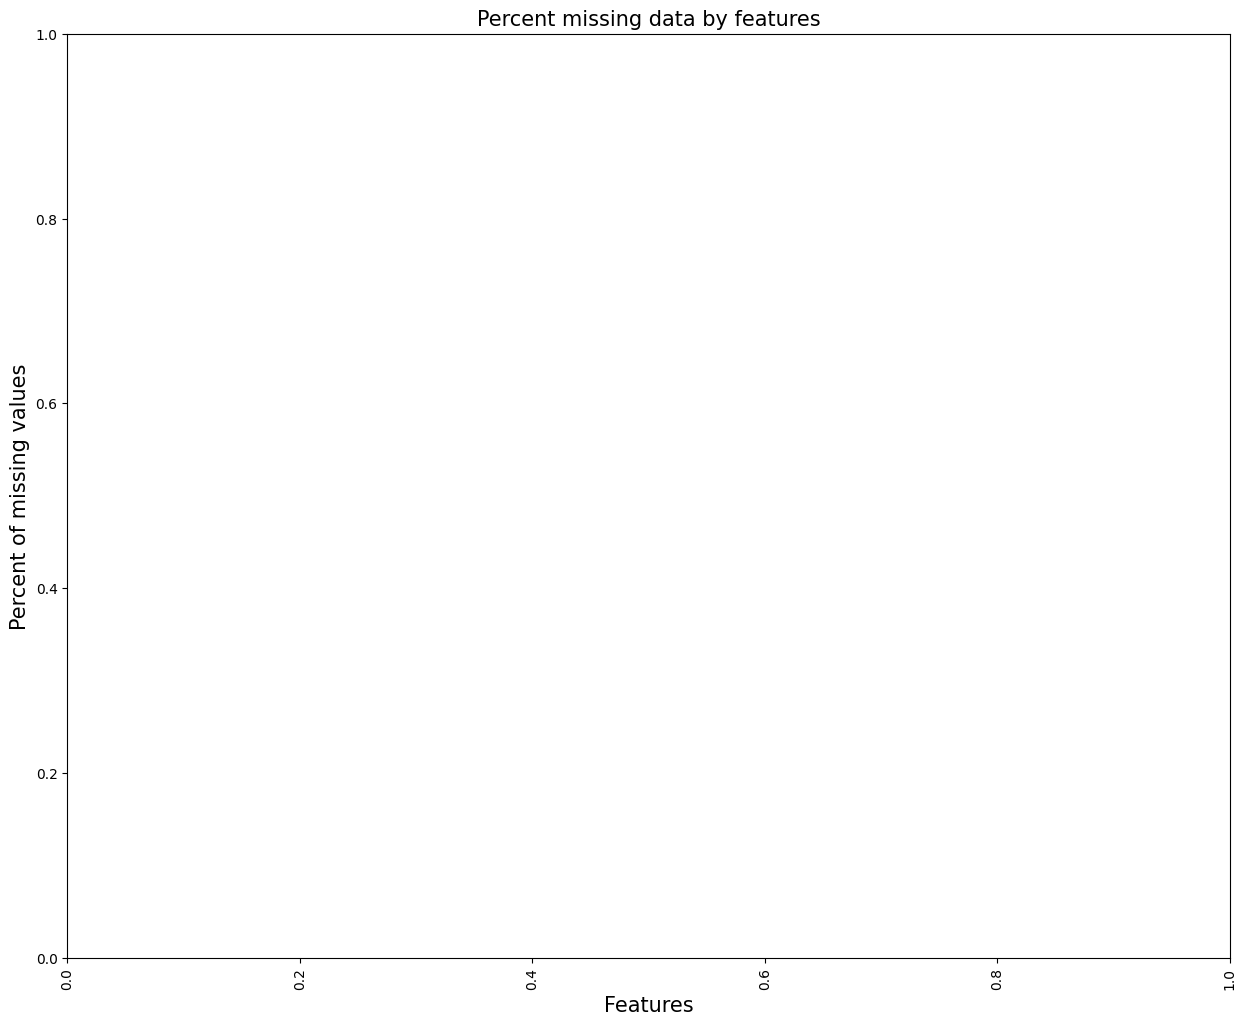

In [ ]:
# Visualize the missing ratios
f, ax = plt.subplots(figsize=(15, 12))
plt.xticks(rotation='vertical')
sns.barplot(x=df_na.index, y=df_na)
plt.xlabel('Features', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by features', fontsize=15)

No values needed to be imputed. However, like we did previously, we will drop columns that are irrelevant.

In [ ]:
#drop first column (app index)
df = df.drop(df.columns[0], axis=1)
#drop id column (doesn't provide valuable information)
df = df.drop('id', axis=1)
#drop track_name column (will not look at app name in algorithms)
df = df.drop('track_name', axis=1)
#drop currency (all USD)
df = df.drop('currency', axis=1)
df.head()

,size_bytes,price,rating_count_tot,rating_count_ver,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,100788224,3.99,21292,26,4.5,6.3.5,4+,Games,38,5,10,1
1,158578688,0.00,161065,26,3.5,8.2.2,4+,Productivity,37,5,23,1
2,100524032,0.00,188583,2822,4.5,5.0.0,4+,Weather,37,5,3,1
3,128512000,0.00,262241,649,4.5,5.10.0,12+,Shopping,37,5,9,1
4,92774400,0.00,985920,5320,5.0,7.5.1,4+,Reference,37,5,45,1


#Feature Engineering

New Feature 1: Binary Feature for free vs. paid apps

In [ ]:
#create a new feature called "is_free" which will be 1 if price is 0.00 and 0 otherwise
df['is_free'] = np.where(df['price'] == 0, 1, 0)
df.head()

,size_bytes,price,rating_count_tot,rating_count_ver,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic,is_free
0,100788224,3.99,21292,26,4.5,6.3.5,4+,Games,38,5,10,1,0
1,158578688,0.00,161065,26,3.5,8.2.2,4+,Productivity,37,5,23,1,1
2,100524032,0.00,188583,2822,4.5,5.0.0,4+,Weather,37,5,3,1,1
3,128512000,0.00,262241,649,4.5,5.10.0,12+,Shopping,37,5,9,1,1
4,92774400,0.00,985920,5320,5.0,7.5.1,4+,Reference,37,5,45,1,1


New Feature 2: ratio of version-specific ratings to total ratings (rating_ratio = rating_count_ver / rating_count_tot)

In [ ]:
# create rating_ratio
#if rating_count_total = 0, automatically set to 0
df['rating_ratio'] = np.where(df['rating_count_tot'] == 0, 0, df['rating_count_ver'] / df['rating_count_tot'])
#describe rating_ratio
df['rating_ratio'].describe()

,rating_ratio
count,6268.000000
mean,0.241688
std,0.335372
min,0.000000
25%,0.009907
50%,0.069144
75%,0.333333
max,1.000000


New Feature 3: extract major version number to indicate if app is updated often

In [ ]:
#extract first number of version
df['major_ver'] = pd.to_numeric(df['ver'].str.extract(r'^(\d+)')[0], errors='coerce').astype('Int64')
df.head()

,size_bytes,price,rating_count_tot,rating_count_ver,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic,is_free,rating_ratio,major_ver
0,100788224,3.99,21292,26,4.5,6.3.5,4+,Games,38,5,10,1,0,0.001221,6
1,158578688,0.00,161065,26,3.5,8.2.2,4+,Productivity,37,5,23,1,1,0.000161,8
2,100524032,0.00,188583,2822,4.5,5.0.0,4+,Weather,37,5,3,1,1,0.014964,5
3,128512000,0.00,262241,649,4.5,5.10.0,12+,Shopping,37,5,9,1,1,0.002475,5
4,92774400,0.00,985920,5320,5.0,7.5.1,4+,Reference,37,5,45,1,1,0.005396,7


In [ ]:
#statistics on major_ver
df['major_ver'].describe()

,major_ver
count,6261.0
mean,18.475004
std,366.556093
min,0.0
25%,1.0
50%,1.0
75%,3.0
max,9999.0


In [ ]:
#remove apps where major_ver is >= 100, tracking indexes of row dropped in order to drop them in y as well
rows_to_drop = df[df['major_ver'] >= 100].index
#drop rows where major_ver is NA
rows_to_drop = rows_to_drop.union(df[df['major_ver'].isna()].index)
df = df.drop(rows_to_drop)
y = y.drop(rows_to_drop)

#drop version column
df = df.drop('ver', axis=1)
df.head()

,size_bytes,price,rating_count_tot,rating_count_ver,user_rating_ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic,is_free,rating_ratio,major_ver
0,100788224,3.99,21292,26,4.5,4+,Games,38,5,10,1,0,0.001221,6
1,158578688,0.00,161065,26,3.5,4+,Productivity,37,5,23,1,1,0.000161,8
2,100524032,0.00,188583,2822,4.5,4+,Weather,37,5,3,1,1,0.014964,5
3,128512000,0.00,262241,649,4.5,12+,Shopping,37,5,9,1,1,0.002475,5
4,92774400,0.00,985920,5320,5.0,4+,Reference,37,5,45,1,1,0.005396,7


In [ ]:
df['major_ver'].describe()

,major_ver
count,6237.0
mean,2.382075
std,3.15813
min,0.0
25%,1.0
50%,1.0
75%,3.0
max,95.0


Label Encoding categorical variables

In [ ]:
from sklearn.preprocessing import LabelEncoder
cols = ('cont_rating',) # Change cols to a tuple

for c in cols:
    lbl = LabelEncoder()
    # encode the categorical features using LabelEncoder
    df[c] = lbl.fit_transform(list(df[c].values))
#shape
df.shape

(6237, 14)

**Skewed Features**

In [ ]:
from scipy.stats import skew

numeric_feats = df.dtypes[df.dtypes != "object"].index

# Check the skew of all numerical features
skewed_feats = df[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness.head(10)


Skew in numerical features: 



,Skew
price,30.984737
rating_count_ver,24.623112
rating_count_tot,18.364827
major_ver,9.880865
size_bytes,4.576796
lang.num,2.706497
rating_ratio,1.399465
is_free,-0.161175
cont_rating,-0.861803
ipadSc_urls.num,-1.368140


**Box Cox Transformation of (highly) skewed features**

In [ ]:
skewness = skewness[abs(skewness) > 0.75]
print("There are {} skewed numerical features to Box Cox transform".format(skewness.shape[0]))

from scipy.special import boxcox1p
skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
    #df[feat] += 1
    df[feat] = boxcox1p(df[feat], lam)

There are 13 skewed numerical features to Box Cox transform


**Getting dummy categorical features**

In [ ]:
df = pd.get_dummies(df)
print(df.shape)


(6237, 36)


In [ ]:
df.head()
#prime_genre is the only feature that needs dummy categorical features

,size_bytes,price,rating_count_tot,rating_count_ver,user_rating_ver,cont_rating,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic,...,prime_genre_News,prime_genre_Photo & Video,prime_genre_Productivity,prime_genre_Reference,prime_genre_Shopping,prime_genre_Social Networking,prime_genre_Sports,prime_genre_Travel,prime_genre_Utilities,prime_genre_Weather
0,99.117388,1.817786,23.059867,4.263161,1.942540,1.194318,4.882973,2.055642,2.885846,0.730463,...,False,False,False,False,False,False,False,False,False,False
1,106.559151,0.000000,33.601265,4.263161,1.687259,1.194318,4.838059,2.055642,4.071754,0.730463,...,False,False,True,False,False,False,False,False,False,False
2,99.075749,0.000000,34.565340,15.287420,1.942540,1.194318,4.838059,2.055642,1.540963,0.730463,...,False,False,False,False,False,False,False,False,False,True
3,103.044364,0.000000,36.655890,10.946837,1.942540,0.000000,4.838059,2.055642,2.750250,0.730463,...,False,False,False,False,True,False,False,False,False,False
4,97.810880,0.000000,46.176040,17.477250,2.055642,1.194318,4.838059,2.055642,5.172535,0.730463,...,False,False,False,True,False,False,False,False,False,False


**Splitting the train and test set**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=42)

# Modelling

#### Regression Model with all features

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

In [ ]:
def average_error_rate(test, pred):
    diff = np.abs(test - pred)
    return np.divide(diff, test).mean()

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
train_mae_ = mean_absolute_error(y_train, y_pred_train)
test_mae_ = mean_absolute_error(y_test, y_pred_test)
train_error_ratio_ = average_error_rate(y_train, y_pred_train)
test_error_ratio_ = average_error_rate(y_test, y_pred_test)
print("Training mean absolute error is: ", train_mae_)
print("Test mean absolute error is: ", test_mae_)
print()
print("Training mean error rate is: ", train_error_ratio_)
print("Test mean error rate is: ", test_error_ratio_)

Training mean absolute error is:  0.46780264301664226
Test mean absolute error is:  0.4497039773774738

Training mean error rate is:  0.14818977767615607
Test mean error rate is:  0.13864551942401643


#####Build Regression model with selected features

In [ ]:
X_train_w_label = X_train.copy()
X_train_w_label['user_rating'] = y_train

# Calculate the correlation matrix
corr_matrix = X_train_w_label.corr()

corr_with_target = corr_matrix['user_rating'].drop('user_rating')

# TODO: get golden_features_list with a correlation
golden_features_list = corr_with_target[abs(corr_with_target) > 0.1].sort_values(ascending=False)

In [ ]:
print (golden_features_list)

user_rating_ver              0.376093
rating_count_ver             0.261267
rating_count_tot             0.245295
prime_genre_Games            0.209925
ipadSc_urls.num              0.165942
size_bytes                   0.146334
lang.num                     0.125203
prime_genre_Sports          -0.116281
prime_genre_Entertainment   -0.139722
Name: user_rating, dtype: float64


In [ ]:
model_selected_features = LinearRegression()

model_selected_features.fit(X_train[golden_features_list.index], y_train)
y_pred_train_ = model_selected_features.predict(X_train[golden_features_list.index])
y_pred_test_ = model_selected_features.predict(X_test[golden_features_list.index])
print("Training mean absolute error is: ", mean_absolute_error(y_train, y_pred_train_))
print("Test mean absolute error is: ", mean_absolute_error(y_test, y_pred_test_))
print()
print("Training mean error rate is: ", average_error_rate(y_train, y_pred_train_))
print("Test mean error rate is: ", average_error_rate(y_test, y_pred_test_))

Training mean absolute error is:  0.4778311144638093
Test mean absolute error is:  0.45493282250033296

Training mean error rate is:  0.15225781725436874
Test mean error rate is:  0.1410584277982218


In [ ]:
# Tune the threshold and find the best features set!
test_mae = [test_mae_]
test_error_ratios = [test_error_ratio_]
features_num = [X_train.shape[1]]

for thre in np.arange(0.01, 0.37, 0.01):
    X_train_corr = X_train_w_label.corr()['user_rating'][:-1] # -1 because the latest row is SalePrice
    golden_features_list = X_train_corr[abs(X_train_corr) >= thre].sort_values(ascending=False)
    features_num.append(len(golden_features_list))

    # Check if golden_features_list is empty
    if golden_features_list.empty:
        print(f"Threshold {thre:.2f} resulted in no selected features. Skipping...")
        continue  # Skip to the next iteration

    model_selected_features.fit(X_train[golden_features_list.index], y_train)
    y_pred_train_ = model_selected_features.predict(X_train[golden_features_list.index])
    y_pred_test_ = model_selected_features.predict(X_test[golden_features_list.index])
    test_mae.append(mean_absolute_error(y_test, y_pred_test_))
    test_error_ratios.append(average_error_rate(y_test, y_pred_test_))

Text(0, 0.5, 'Number of Features')

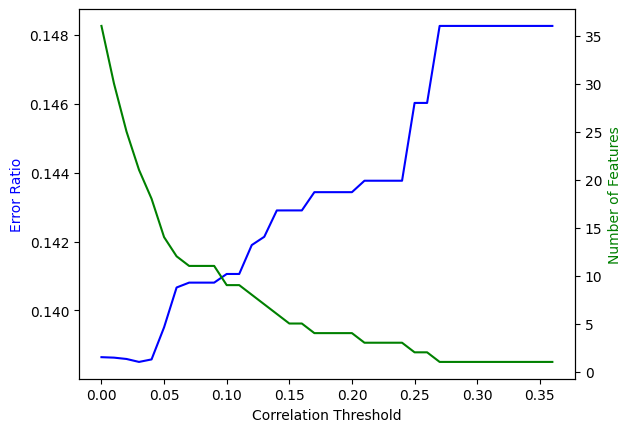

In [ ]:
# Plot features vs.
x_plot = np.arange(0.0,0.37,0.01)

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(x_plot, test_error_ratios, 'b-')
ax2.plot(x_plot, features_num, 'g-')

ax1.set_xlabel('Correlation Threshold')
ax1.set_ylabel('Error Ratio', color='b')
ax2.set_ylabel('Number of Features', color='g')

In [ ]:
# Import sequenctial features selector as SFS
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [ ]:
sfs = SFS(model, k_features=36, forward=True, scoring='neg_mean_absolute_error', cv=3)
sfs = sfs.fit(X_train, y_train)

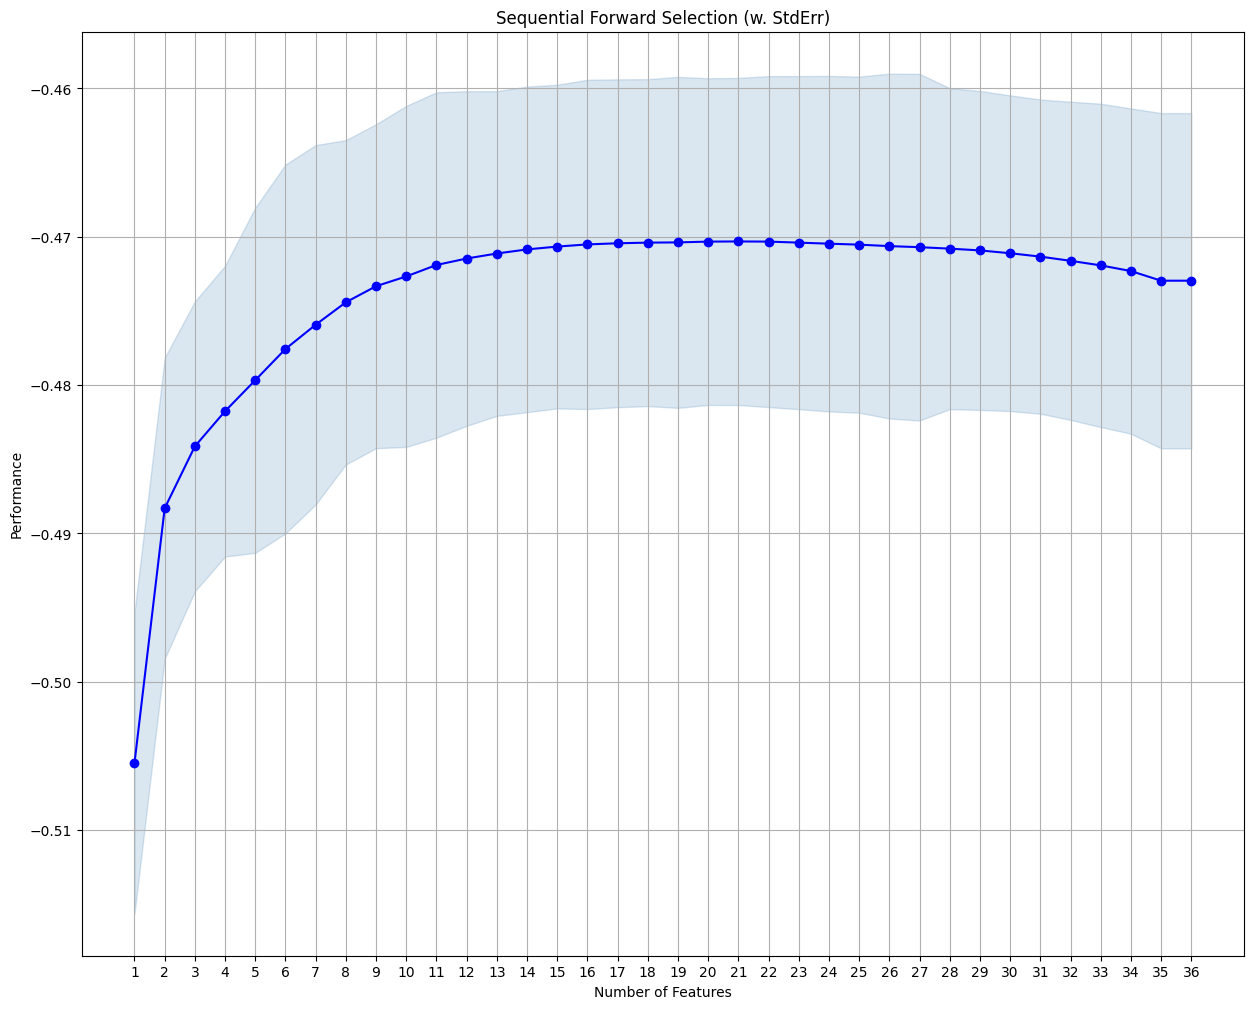

In [ ]:
fig = plot_sfs(sfs.get_metric_dict(), kind='std_err', figsize=(15, 12))

plt.title('Sequential Forward Selection (w. StdErr)')
plt.grid()
plt.show()

In [ ]:
# TODO: use SequentialFeatureSelector to run a step backward feature selection
# you can set the parameters: features - down to 1, scoring -'neg_mean_absolute_error', cv=3
# Note: you can also use a larger n_jobs to speed up computation
sfs_backward = SFS(model, k_features=1, forward=False, scoring='neg_mean_absolute_error', cv=3)

sfs_backward = sfs_backward.fit(X_train, y_train)

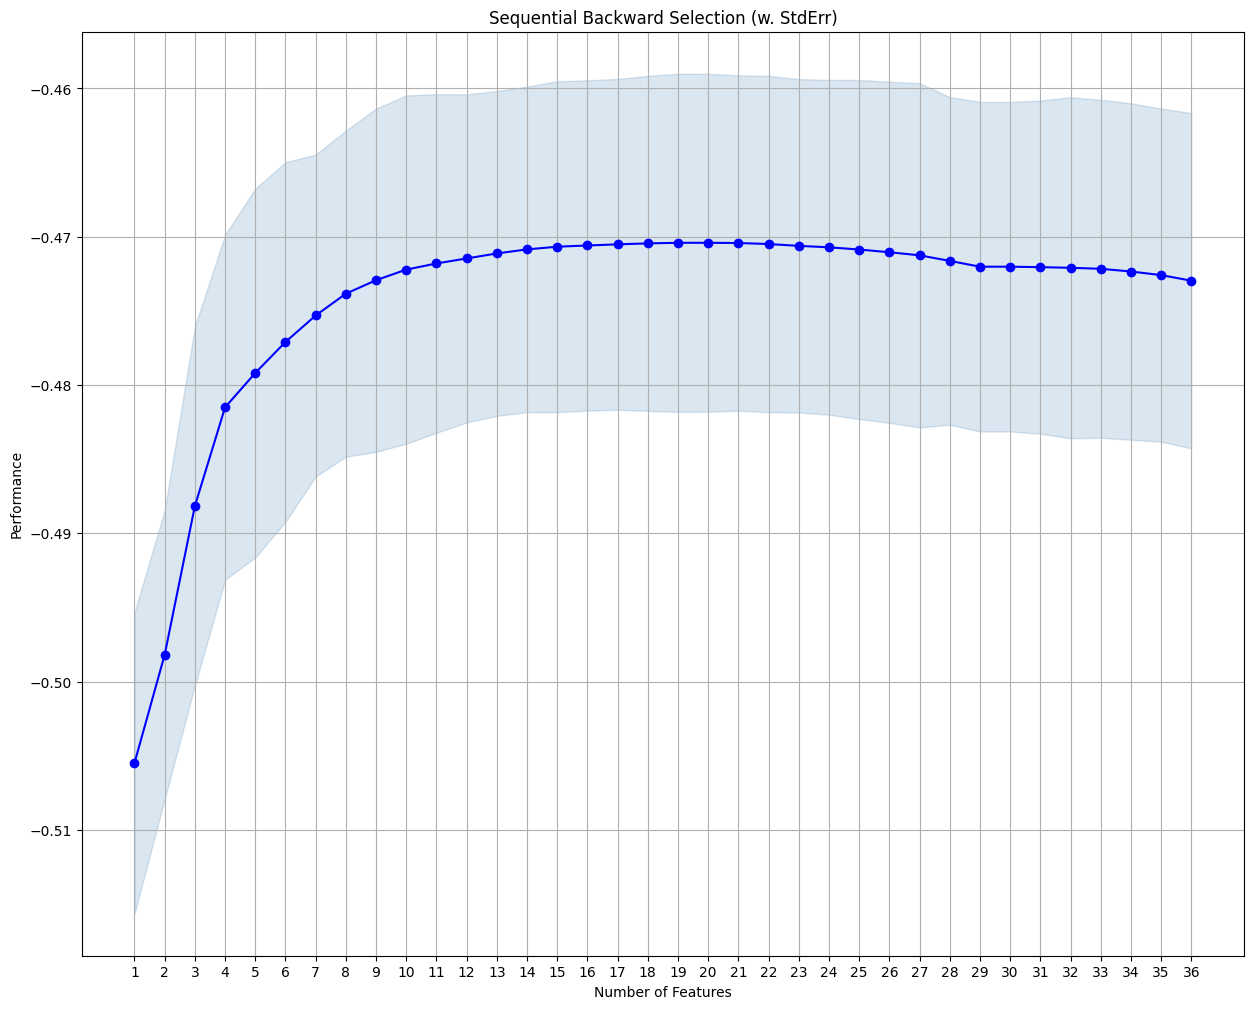

In [ ]:
fig = plot_sfs(sfs_backward.get_metric_dict(), kind='std_err', figsize=(15, 12))

plt.title('Sequential Backward Selection (w. StdErr)')
plt.grid()
plt.show()